# `process(StateChange)` — Inducing Dyslexia in CLIP

Demonstrates the `state_change_fn` mechanism using a Honarmand-style induced-dyslexia paradigm — a standard setup in the brain-score behavioral toolkit:

1. **Test stimuli**: word images (real words + pseudowords)
2. **Localizer stimuli**: a separate set of (real, pseudo) word images used to identify *which* units in CLIP are most word-selective
3. **Lesion**: ablate those word-selective units via `process(StateChange(...))`
4. **Re-test**: see how the model's discrimination of real vs pseudo collapses
5. **Reset**: confirm restoration

This is the same shape Honarmand et al. (2026) used for inducing dyslexia in VLMs. Here we use CLIP because it's small and fast — the mechanism transfers directly to Qwen / BLIP-2 / etc.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from transformers import CLIPProcessor

import brainscore
import brainscore_vision  # registers CLIP
from brainscore_core.model_interface import (
    StateChange, Selection, Perturbation,
)
from brainscore.perturbation import build_pytorch_ablation_fn


def render_word_image(word, size=224, font_size=56):
    """Render `word` as black text on a white 224x224 image."""
    img = Image.new('RGB', (size, size), color='white')
    draw = ImageDraw.Draw(img)
    for path in ['/System/Library/Fonts/Helvetica.ttc',
                 '/System/Library/Fonts/Supplemental/Arial.ttf',
                 '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf']:
        try:
            font = ImageFont.truetype(path, font_size)
            break
        except (OSError, IOError):
            continue
    else:
        font = ImageFont.load_default()
    bbox = draw.textbbox((0, 0), word, font=font)
    x = (size - (bbox[2] - bbox[0])) // 2 - bbox[0]
    y = (size - (bbox[3] - bbox[1])) // 2 - bbox[1]
    draw.text((x, y), word, fill='black', font=font)
    return img


/Users/kartik/Brain-Score Unified/core/brainscore_core/metrics/__init__.py:16: FutureWarning: xarray subclass Score should explicitly define __slots__
  class Score(DataAssembly):


## 1. Stimuli

Two stimulus sets:
- **Test set** (4 real + 4 pseudo): held out, used to measure the behavioral effect of the lesion.
- **Localizer** (8 real + 8 pseudo): a separate pool used only to identify *which* units are word-selective. The test set never participates in selecting the lesion target.

In [2]:
TEST_REAL    = ['apple', 'table', 'ocean', 'school']
TEST_PSEUDO  = ['blapt', 'fronk', 'mishel', 'pringol']

LOC_REAL     = ['mountain', 'forest', 'sunset', 'tiger',
                'doctor',  'garden', 'rocket', 'river']
LOC_PSEUDO   = ['plapp',    'snorel', 'graspol','mendrel',
                'flarbon', 'tronkel','vendel', 'krimsel']

test_imgs    = [render_word_image(w) for w in TEST_REAL + TEST_PSEUDO]
test_labels  = (['real:'   + w for w in TEST_REAL]
                + ['pseudo:' + w for w in TEST_PSEUDO])
loc_real_imgs   = [render_word_image(w) for w in LOC_REAL]
loc_pseudo_imgs = [render_word_image(w) for w in LOC_PSEUDO]

print(f'Test set:      {len(test_imgs)} images '
      f'({len(TEST_REAL)} real + {len(TEST_PSEUDO)} pseudo)')
print(f'Localizer set: {len(loc_real_imgs) + len(loc_pseudo_imgs)} images '
      f'({len(LOC_REAL)} real + {len(LOC_PSEUDO)} pseudo)')


Test set:      8 images (4 real + 4 pseudo)
Localizer set: 16 images (8 real + 8 pseudo)


### Display the stimuli

Top row: the test set. Bottom rows: the localizer (left half real, right half pseudo). Note the rendered images are exactly what CLIP will see — the same pipeline that handles a real-world brain-score benchmark stimulus set.

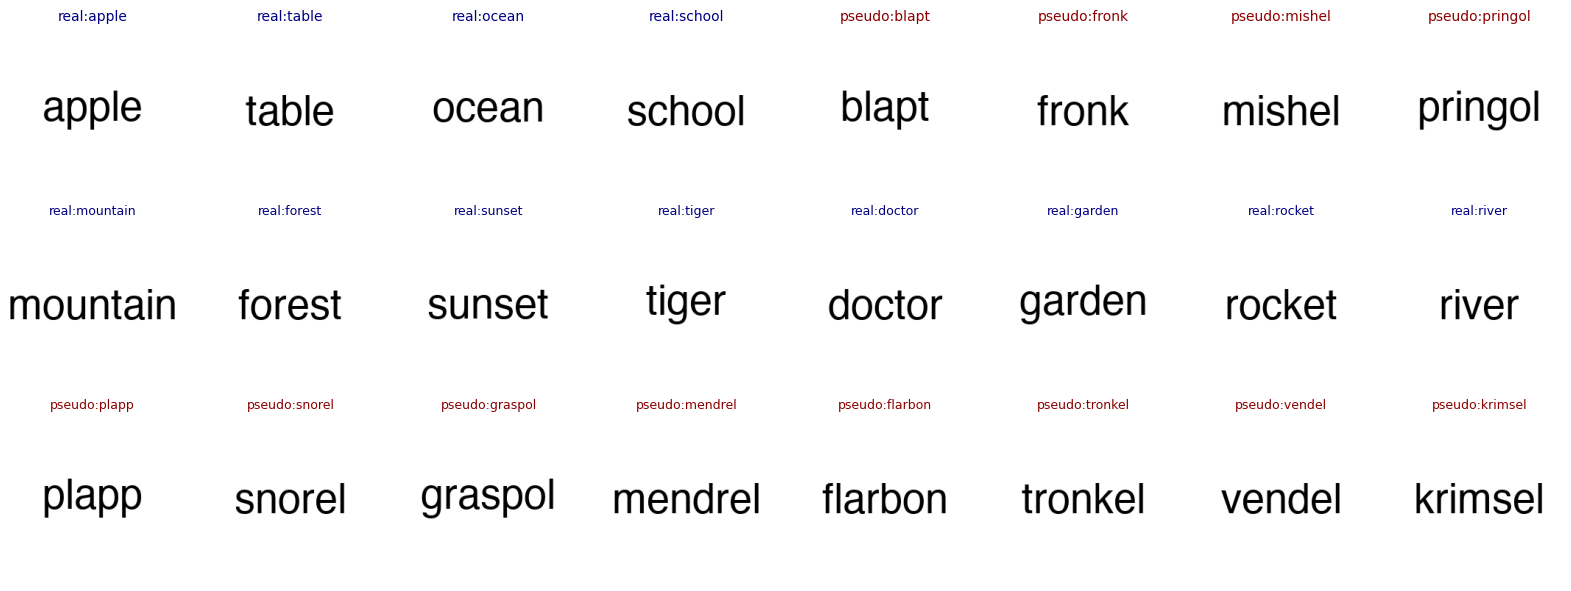

In [3]:
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

# Row 0: test set (4 real on left, 4 pseudo on right)
for i, (img, lbl) in enumerate(zip(test_imgs, test_labels)):
    axes[0, i].imshow(img)
    color = 'navy' if lbl.startswith('real') else 'darkred'
    axes[0, i].set_title(lbl, fontsize=10, color=color)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('TEST', fontsize=12, fontweight='bold',
                     rotation=0, ha='right', va='center')

# Rows 1-2: localizer (real then pseudo)
for i, (img, w) in enumerate(zip(loc_real_imgs, LOC_REAL)):
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'real:{w}', fontsize=9, color='navy')
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('LOCALIZER\nreal', fontsize=11, fontweight='bold',
                      rotation=0, ha='right', va='center')

for i, (img, w) in enumerate(zip(loc_pseudo_imgs, LOC_PSEUDO)):
    axes[2, i].imshow(img)
    axes[2, i].set_title(f'pseudo:{w}', fontsize=9, color='darkred')
    axes[2, i].axis('off')
axes[2, 0].set_ylabel('LOCALIZER\npseudo', fontsize=11, fontweight='bold',
                      rotation=0, ha='right', va='center')

plt.tight_layout()
plt.show()


## 2. Load CLIP and wire `state_change_fn`

Pull CLIP via the brain-score registry, then attach a `state_change_fn` using the helper `build_pytorch_ablation_fn`. This is the explicit form of what a model registration would do internally.

In [4]:
bs_model = brainscore.load_model('clip-vit-b-32')
clip_model = bs_model._model.to('cpu').eval()
processor  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

bs_model._state_change_fn = build_pytorch_ablation_fn(clip_model)
print(f'state_change_fn wired: {bs_model._state_change_fn is not None}')


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


state_change_fn wired: True


## 3. Localize word-selective units

Run the localizer through CLIP's vision encoder, capture activations at `vision_model.encoder.layers.10` (the layer used as 'IT' in CLIP's region map), and compute a per-unit selectivity = `mean(activation on real words) − mean(activation on pseudo words)`.

Units with high positive selectivity light up more for real words than pseudo — these are our VWFA-analog targets for ablation.

In [5]:
TARGET_LAYER_PATH = 'vision_model.encoder.layers.10'
target_layer = clip_model.vision_model.encoder.layers[10]
captured = []

def _hook(_m, _i, output):
    h = output[0] if isinstance(output, tuple) else output
    captured.append(h.detach().cpu().numpy())

def encode_images(imgs):
    """Run images through CLIP vision tower, return per-image
    layer-10 mean-token activations as (N, hidden_dim)."""
    captured.clear()
    h = target_layer.register_forward_hook(_hook)
    with torch.no_grad():
        for im in imgs:
            inp = processor(images=im, return_tensors='pt')
            clip_model.vision_model(pixel_values=inp['pixel_values'])
    h.remove()
    return np.concatenate([a.mean(axis=1) for a in captured], axis=0)

loc_real_act   = encode_images(loc_real_imgs)
loc_pseudo_act = encode_images(loc_pseudo_imgs)
selectivity = loc_real_act.mean(0) - loc_pseudo_act.mean(0)

TOP_K = 80
vwfa_units = np.argsort(selectivity)[-TOP_K:].tolist()

print(f'Hidden dim: {selectivity.shape[0]}')
print(f'Selectivity range: [{selectivity.min():+.3f}, {selectivity.max():+.3f}]')
print(f'Top-{TOP_K} VWFA-analog units identified.')


Hidden dim: 768
Selectivity range: [-0.187, +0.136]
Top-80 VWFA-analog units identified.


## 4. Score test stimuli — baseline, then under lesion, then reset

For each test image, we measure how much it matches a `"real word"` caption vs a `"non-word"` caption. A reading-capable model should score higher on the matching caption (real images → real caption, pseudo images → non-word caption).

We run this three times: baseline → after `process(StateChange(...))` ablation → after `model.reset()`.

In [6]:
PROBE_REAL  = 'a photograph of a real English word'
PROBE_PSEUDO = 'a photograph of a made-up non-word string of letters'

def score_all(imgs):
    """Cosine similarity of each image to (real-word, non-word) probes.
    Returns array of shape (N_imgs, 2)."""
    out = []
    for im in imgs:
        inp = processor(images=im, text=[PROBE_REAL, PROBE_PSEUDO],
                        return_tensors='pt', padding=True)
        with torch.no_grad():
            o = clip_model(**inp)
        ie = o.image_embeds  / o.image_embeds.norm(dim=-1, keepdim=True)
        te = o.text_embeds   / o.text_embeds.norm(dim=-1, keepdim=True)
        out.append((ie @ te.T)[0].cpu().numpy())
    return np.array(out)  # (N, 2)

baseline_sims = score_all(test_imgs)  # before ablation

applied = bs_model.process(StateChange(
    kind='ablation',
    target=Selection(layer=TARGET_LAYER_PATH, indices=vwfa_units),
    perturbation=Perturbation(kind='zero'),
))
print(f'Lesion installed — handle_id: {applied.handle_id[:12]}... '
      f'(active: {len(bs_model._active_perturbations)})')

ablated_sims = score_all(test_imgs)  # under lesion
bs_model.reset()
restored_sims = score_all(test_imgs)  # after reset

assert np.allclose(baseline_sims, restored_sims, atol=1e-5), 'reset failed'
print('reset() restored baseline outputs bit-for-bit.')


Lesion installed — handle_id: 3dae11b3-48f... (active: 1)


reset() restored baseline outputs bit-for-bit.


## 5. Visualize

Four panels:
- **(top-left)** Per-unit word selectivity from the localizer. Red dashed line = ablation threshold; the top 80 units to the right of the line are zeroed.
- **(top-right)** Layer activations for one test image, units sorted by selectivity. Red shaded region = ablated zone — those units are now zero.
- **(bottom-left)** Baseline cosine similarity of each test image to the two probes. Real-word images should lean toward the navy bar (`real word` probe); pseudo toward the grey bar (`non-word` probe).
- **(bottom-right)** Same chart after the lesion. Discrimination should weaken — reduced gap between bars, fewer images aligned with their correct probe.

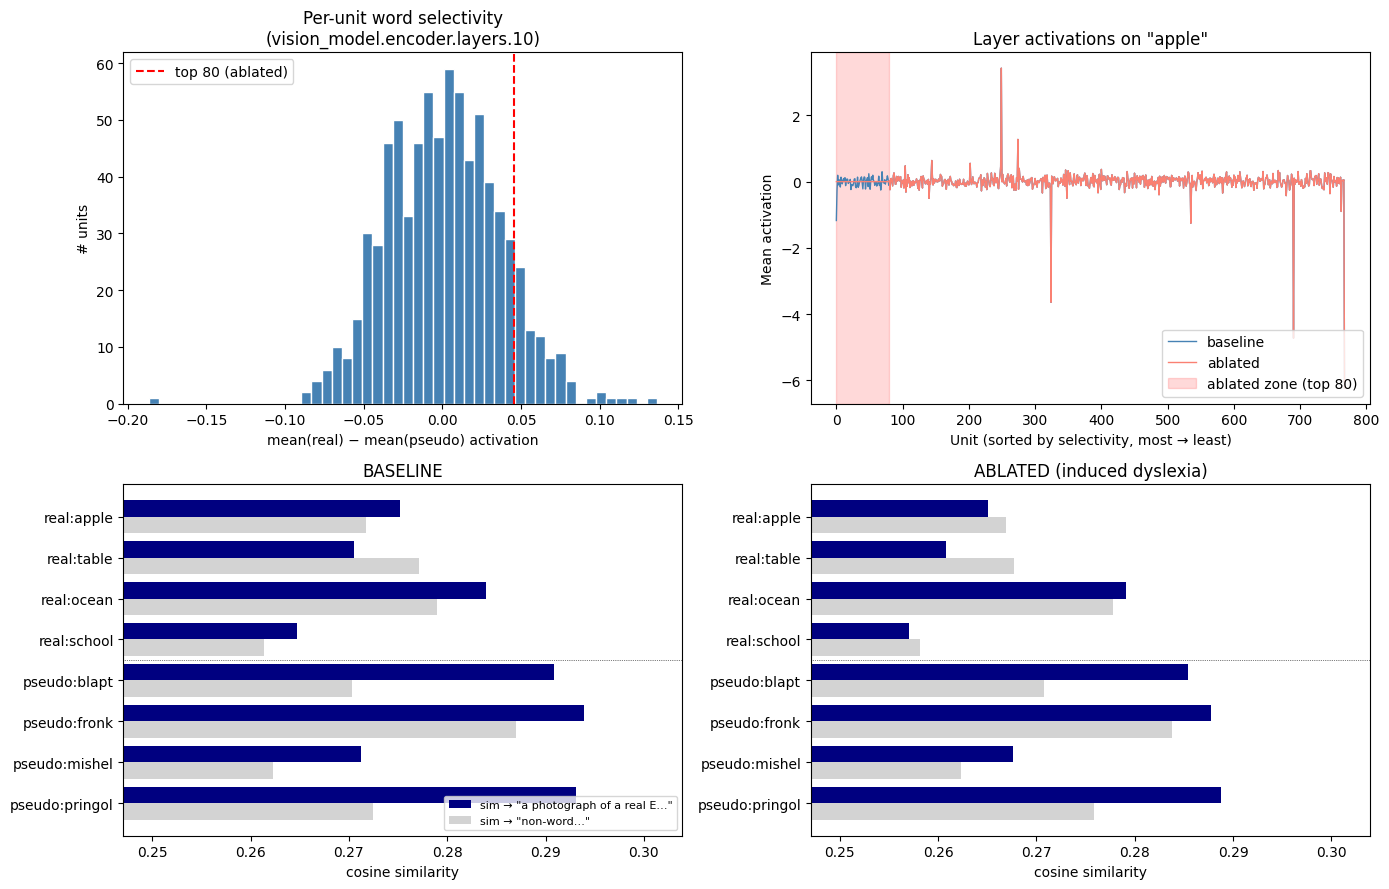


Discrimination gap (correct probe minus wrong probe), baseline → ablated:
  real-word images:   +0.0013  →  -0.0021
  pseudo-word images: -0.0143  →  -0.0092


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (0, 0) — selectivity histogram
axes[0, 0].hist(selectivity, bins=50, color='steelblue', edgecolor='white')
thr = selectivity[vwfa_units].min()
axes[0, 0].axvline(thr, color='red', ls='--',
                   label=f'top {TOP_K} (ablated)')
axes[0, 0].set_xlabel('mean(real) − mean(pseudo) activation')
axes[0, 0].set_ylabel('# units')
axes[0, 0].set_title(f'Per-unit word selectivity\n({TARGET_LAYER_PATH})')
axes[0, 0].legend()

# (0, 1) — activations on first real-word test stim, baseline vs ablated
captured.clear()
h = target_layer.register_forward_hook(_hook)
with torch.no_grad():
    inp = processor(images=test_imgs[0], return_tensors='pt')
    clip_model.vision_model(pixel_values=inp['pixel_values'])
h.remove()
act_baseline = captured[0].mean(axis=(0, 1))  # (768,)

applied2 = bs_model.process(StateChange(
    kind='ablation',
    target=Selection(layer=TARGET_LAYER_PATH, indices=vwfa_units),
    perturbation=Perturbation(kind='zero'),
))
captured.clear()
h = target_layer.register_forward_hook(_hook)
with torch.no_grad():
    clip_model.vision_model(pixel_values=inp['pixel_values'])
h.remove()
act_ablated = captured[0].mean(axis=(0, 1))
bs_model.reset()

order = np.argsort(selectivity)[::-1]  # most word-selective first
axes[0, 1].plot(act_baseline[order], color='steelblue', label='baseline', lw=1)
axes[0, 1].plot(act_ablated[order], color='salmon', label='ablated', lw=1)
axes[0, 1].axvspan(0, TOP_K, alpha=0.15, color='red',
                   label=f'ablated zone (top {TOP_K})')
axes[0, 1].set_xlabel('Unit (sorted by selectivity, most → least)')
axes[0, 1].set_ylabel('Mean activation')
axes[0, 1].set_title(f'Layer activations on "{TEST_REAL[0]}"')
axes[0, 1].legend(loc='lower right')

# Bottom row: per-stimulus probe similarities
y = np.arange(len(test_imgs))
width = 0.4
for ax, sims, title in [
        (axes[1, 0], baseline_sims, 'BASELINE'),
        (axes[1, 1], ablated_sims,  'ABLATED (induced dyslexia)'),
]:
    ax.barh(y - width/2, sims[:, 0], height=width,
            color='navy',  label=f'sim → "{PROBE_REAL[:24]}…"')
    ax.barh(y + width/2, sims[:, 1], height=width,
            color='lightgrey', label=f'sim → "non-word…"')
    ax.set_yticks(y)
    ax.set_yticklabels(test_labels)
    ax.invert_yaxis()
    ax.set_xlabel('cosine similarity')
    ax.set_title(title)
    ax.axhline(len(TEST_REAL) - 0.5, color='black', lw=0.5, ls=':')
axes[1, 0].legend(loc='lower right', fontsize=8)

# Match x-axes for direct visual comparison
lo = min(baseline_sims.min(), ablated_sims.min()) - 0.01
hi = max(baseline_sims.max(), ablated_sims.max()) + 0.01
axes[1, 0].set_xlim(lo, hi)
axes[1, 1].set_xlim(lo, hi)

plt.tight_layout()
plt.show()

# Numerical summary
real_gap_baseline  = (baseline_sims[:len(TEST_REAL), 0]
                      - baseline_sims[:len(TEST_REAL), 1]).mean()
real_gap_ablated   = (ablated_sims[:len(TEST_REAL), 0]
                      - ablated_sims[:len(TEST_REAL), 1]).mean()
pseudo_gap_baseline = (baseline_sims[len(TEST_REAL):, 1]
                       - baseline_sims[len(TEST_REAL):, 0]).mean()
pseudo_gap_ablated  = (ablated_sims[len(TEST_REAL):, 1]
                       - ablated_sims[len(TEST_REAL):, 0]).mean()
print()
print('Discrimination gap (correct probe minus wrong probe), baseline → ablated:')
print(f'  real-word images:   {real_gap_baseline:+.4f}  →  {real_gap_ablated:+.4f}')
print(f'  pseudo-word images: {pseudo_gap_baseline:+.4f}  →  {pseudo_gap_ablated:+.4f}')


## What this enables

- **Causal contribution measurement**: the discrimination gap before/after the lesion is the causal contribution of those localizer-identified units to word recognition.
- **Localizer pattern**: same shape as the brain-score *fROI*-based scoring used elsewhere — a localizer to identify functional units, then a held-out test set to measure the lesion's effect.
- **Honarmand-style induced dyslexia**: replace CLIP with Qwen / BLIP-2 and use a real ROAR test set; replace the cosine probe with the model's `generation_fn`. The `process(StateChange(...))` mechanics are identical.
- **Selective undo**: `process(StateChange(kind='reset', handle_id=...))` removes one perturbation at a time, so multi-region lesion experiments compose cleanly.

All the brain-score side ships from a single `BrainScoreModel` — no subclassing, no benchmark-side branching.